# Netflix Movies and TV Shows — End-to-End EDA
**Author:** Neethu Reddy Singireddy  
**Dataset:** `netflix_titles.csv` (8,807 titles, 12 columns)

## 1. Project Overview
This notebook walks through a complete real-world analytics workflow on Netflix's public catalogue:
data cleaning → feature engineering → exploratory data analysis → business insights.

## 2. Business Problem
Netflix is one of the world's largest streaming platforms with thousands of titles across dozens of
countries. Content strategy teams need to know:

* What kind of content dominates the platform (movies vs TV)?
* Which countries and genres drive the catalogue?
* How has the mix evolved over time?
* Which ratings, durations, and release-cadence patterns are typical?

Answering these questions helps content acquisition, marketing and localisation teams make
data-driven decisions.

## 3. Dataset Description
| Column | Description |
|---|---|
| `show_id` | Unique ID for each title |
| `type` | Movie or TV Show |
| `title` | Name of the title |
| `director` | Director(s) |
| `cast` | Main cast |
| `country` | Country/countries of production |
| `date_added` | Date title was added to Netflix |
| `release_year` | Year the title was released |
| `rating` | TV/Film rating (PG, TV-MA, …) |
| `duration` | Minutes (movies) or seasons (TV) |
| `listed_in` | Genres |
| `description` | Short synopsis |


## 4. Setup

In [1]:
import sys, os
# Make the sibling `src` package importable when the notebook lives in /notebooks
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 40)
sns.set_theme(style='whitegrid', context='talk')

from src import cleaning, analysis, visualization as viz

## 5. Load & Inspect the Raw Data

In [2]:
DATA_PATH = '../data/netflix_titles.csv'
raw = cleaning.load_data(DATA_PATH)
raw.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
raw.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [4]:
cleaning.inspect_data(raw)

Shape           : (8807, 12)
Columns         : ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Dtypes:
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

Missing values per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicated rows : 0


**Observations (raw data)**  
* 8,807 rows × 12 columns.  
* Heavy missingness in `director` (~30%) and `cast` (~9%).  
* `date_added` is stored as string — must be parsed for time-series work.  
* `duration` mixes minutes (movies) and seasons (TV) in one column — needs splitting.


## 6. Data Cleaning
Every step below has a clear **WHY**.

| Step | Why |
|---|---|
| Rename `listed_in` → `genres`, `type` → `content_type` | `type` shadows a Python builtin; `listed_in` is unintuitive |
| Strip whitespace + standardise text | Prevents phantom duplicates on group-bys |
| Fill missing `director`/`cast`/`country` with `Unknown` | Dropping would lose thousands of rows |
| Drop rows with missing `date_added` | Only ~10 rows; keeps time-series clean |
| Convert `date_added` → datetime | Required for `year_added`, `month_added` features |
| Split multi-value columns into lists | Enables `.explode()` for per-genre / per-country analytics |
| Extract numeric minutes and seasons from `duration` | Separates movies and TV for clean duration analysis |


In [5]:
df = cleaning.clean_pipeline(DATA_PATH)
cleaning.verify_clean(df)

Removed 0 duplicate rows
Final shape       : (8797, 20)
Missing per column (expected: duration_minutes NaN for TV Shows,
                   duration_seasons NaN for Movies -- by design)
show_id                0
content_type           0
title                  0
director               0
cast                   0
country                0
date_added             0
release_year           0
rating                 0
duration               0
genres                 0
description            0
year_added             0
month_added            0
month_added_name       0
genres_list            0
countries_list         0
cast_list              0
duration_minutes    2666
duration_seasons    6131
dtype: int64
Duplicates        : 0
Date range        : 2008-01-01 00:00:00 -> 2021-09-25 00:00:00


In [6]:
df.head(3)

,show_id,content_type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,year_added,month_added,month_added_name,genres_list,countries_list,cast_list,duration_minutes,duration_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,September,[Documentaries],[United States],[Unknown],90.0,NaN
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,September,"[International TV Shows, TV Dramas, TV Mysteries]",[South Africa],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,September,"[Crime TV Shows, International TV Shows, TV Ac...",[Unknown],"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...",NaN,1.0


### 6.1 Visualising missing values (before cleaning)

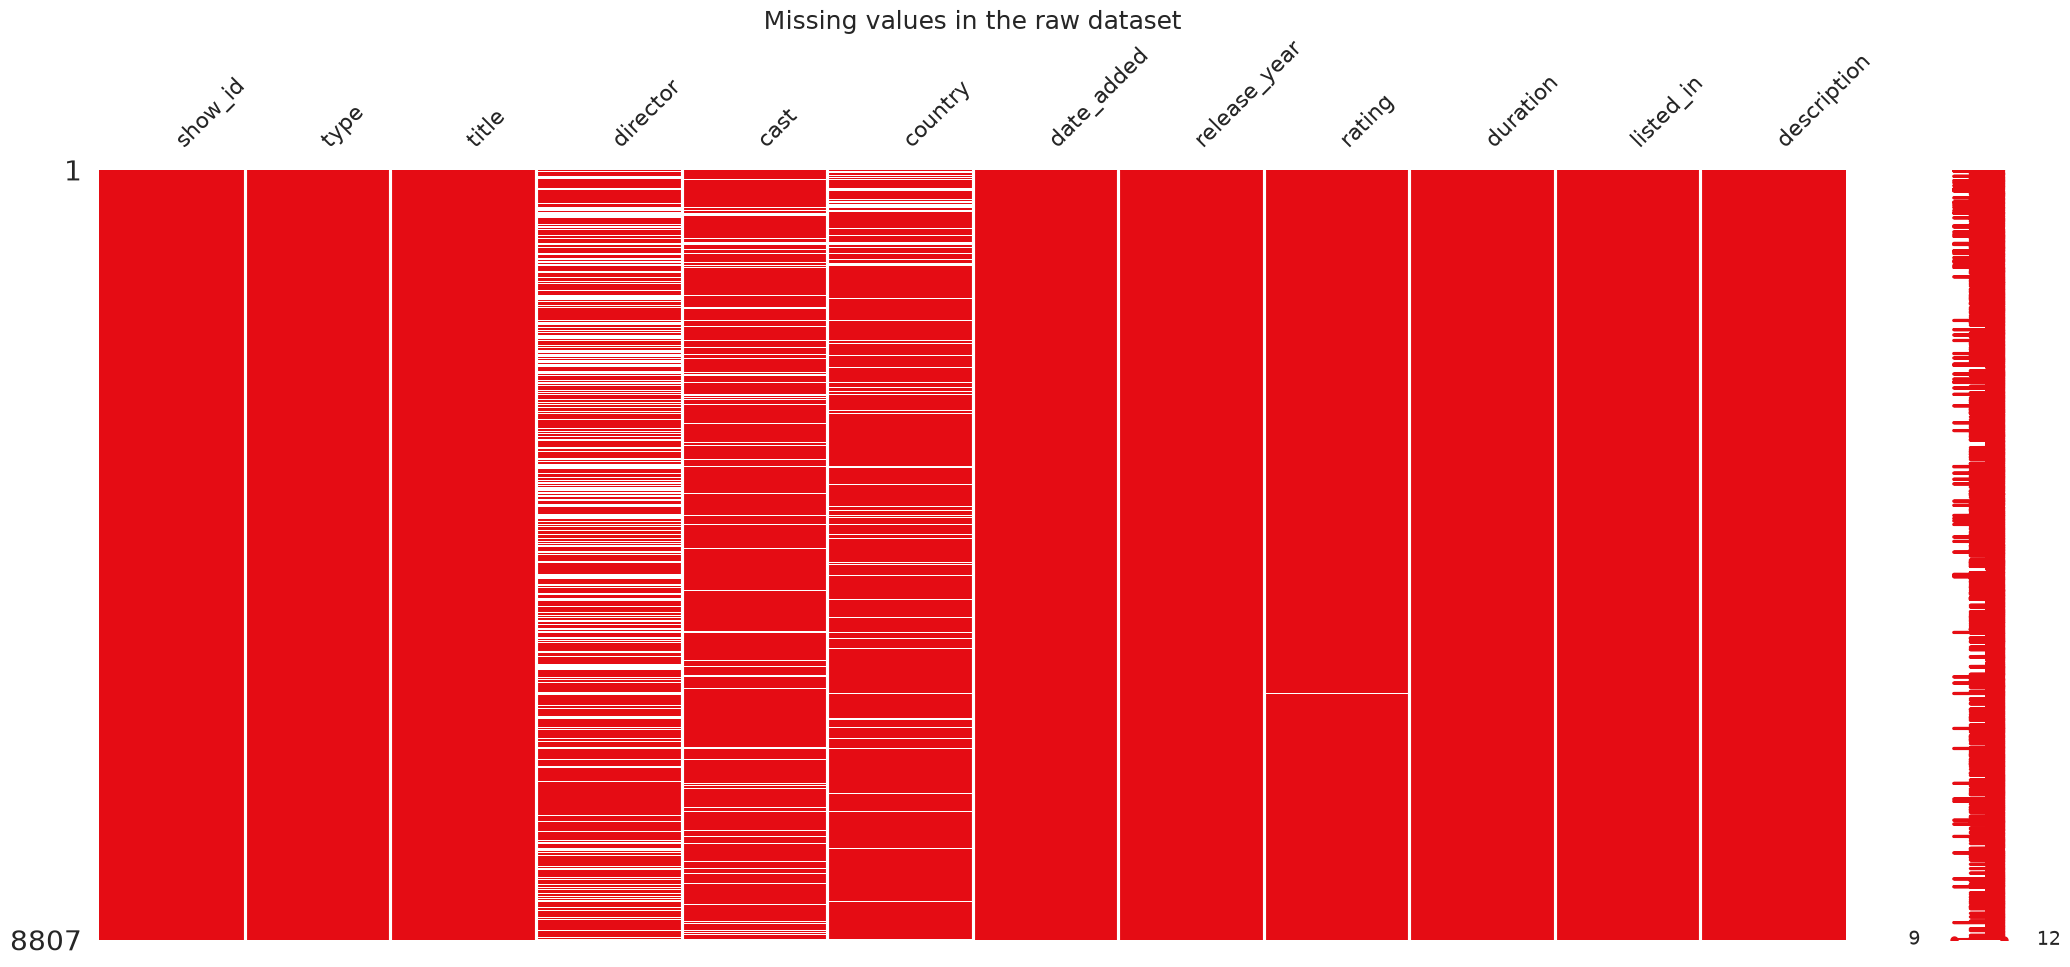

In [7]:
try:
    import missingno as msno
    msno.matrix(raw, color=(0.9, 0.05, 0.08))
    plt.title('Missing values in the raw dataset')
    plt.show()
except ImportError:
    print('missingno not installed — skipping missing-value matrix')

## 7. Exploratory Data Analysis

### Q1. Which country produces the most Netflix content?

In [8]:
top_c = analysis.top_countries(df, 10)
top_c

countries_list
United States     3684
India             1046
United Kingdom     805
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

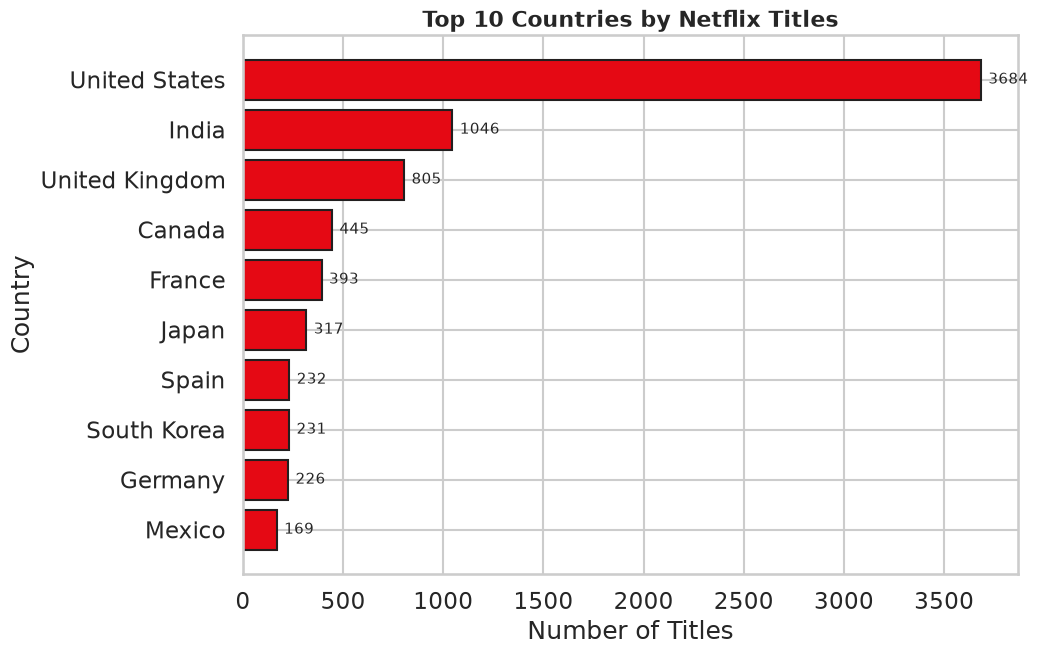

In [9]:
viz.plot_top_countries(df, n=10);

**Insights**
* The **United States** dwarfs every other country, contributing ~2.8× more titles than the runner-up.
* **India** is #2, reflecting Netflix's aggressive push into the Indian original-content market.
* Together the top 3 (US, India, UK) account for **>50%** of the catalogue — a heavy geographic concentration.
* European nations (France, Spain, Germany) form the next tier and are prime targets for regional expansion.


### Q2. Movies vs TV Shows

In [10]:
analysis.content_type_breakdown(df)

,count,percentage
content_type,,
Movie,6131,69.69
TV Show,2666,30.31


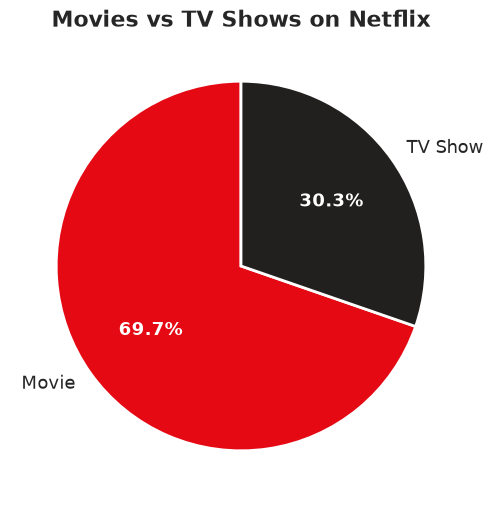

In [11]:
viz.plot_content_type_pie(df);

**Insights**
* Movies account for **~70%** of Netflix's catalogue, TV Shows ~30%.
* Feature-length content is still the volume driver, but series command higher watch-time per title.
* The 70/30 mix has stayed relatively stable — Netflix has not pivoted its catalogue balance despite big spend on originals.


### Q3. Which genres are the most common?

In [12]:
analysis.top_genres(df, 15)

genres_list
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
TV Comedies                  574
Crime TV Shows               469
Kids' TV                     449
Docuseries                   394
Name: count, dtype: int64

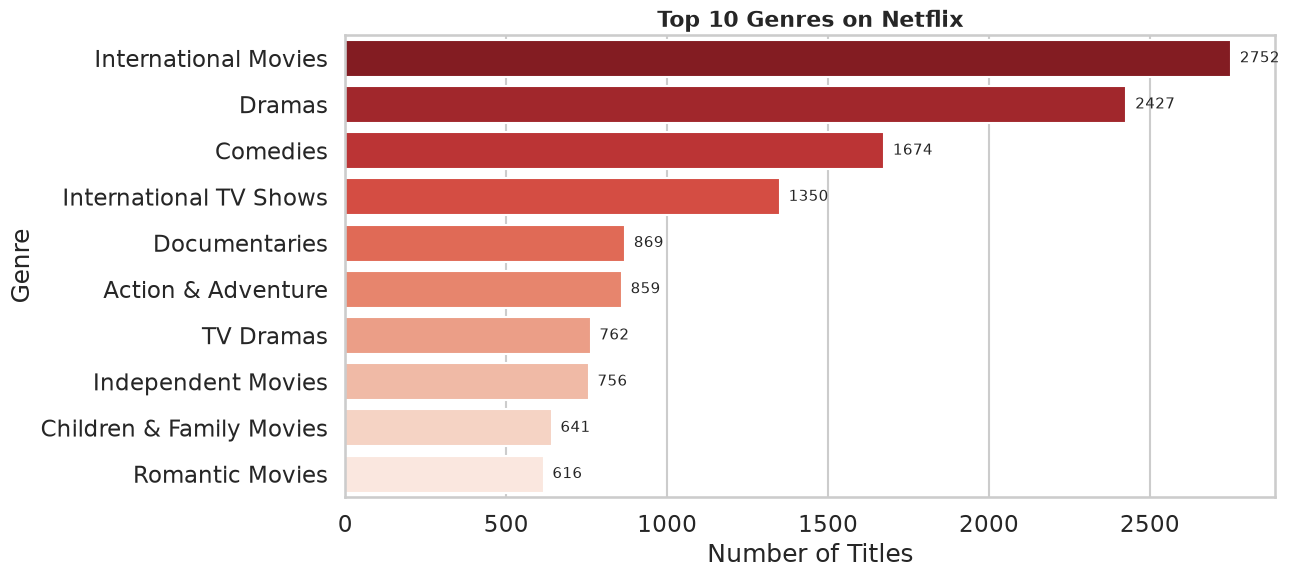

In [13]:
viz.plot_top_genres(df, n=10);

**Insights**
* **International Movies**, **Dramas** and **Comedies** dominate — Netflix is a global-first drama platform.
* Documentaries rank surprisingly high, showing strong investment in non-fiction storytelling.
* Kids/Family sits mid-table — a growth lever, given the profitability of that segment for competitors like Disney+.


### Q4. Which ratings are most common?

In [14]:
analysis.rating_distribution(df).head(10)

rating
TV-MA    3209
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

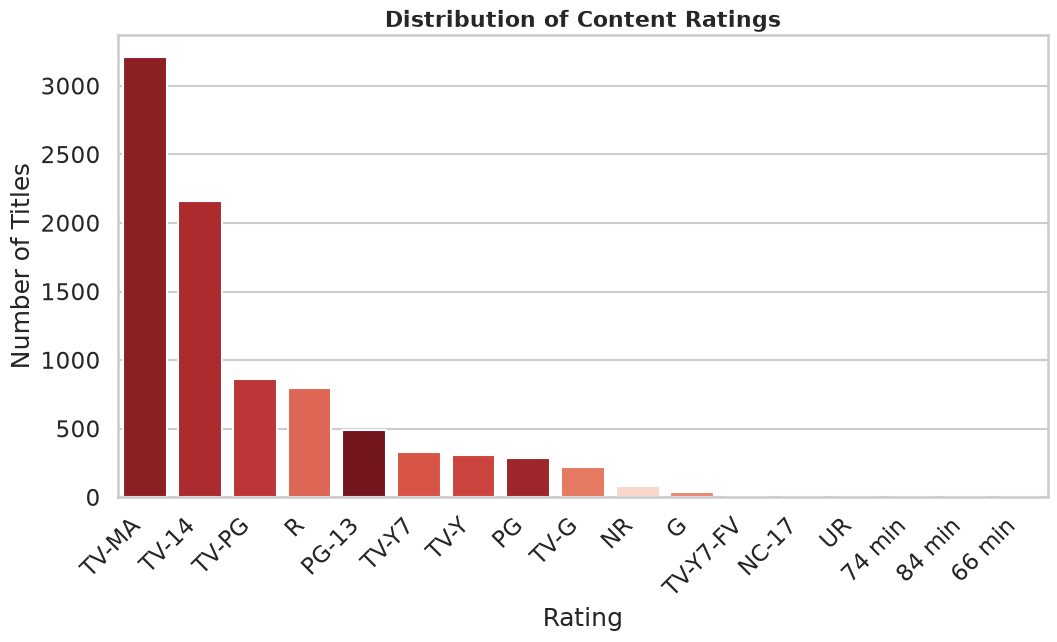

In [15]:
viz.plot_rating_distribution(df);

**Insights**
* **TV-MA** (mature audiences) is the single most common rating — Netflix leans adult.
* TV-14 and TV-PG follow, indicating a strong young-adult / teen audience layer.
* Only a small share of content is rated for young children (G, TV-Y), a gap vs Disney+ and Amazon.


### Q5. Content added over time

In [16]:
yearly = analysis.yearly_additions(df)
yearly.tail(10)

year_added
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

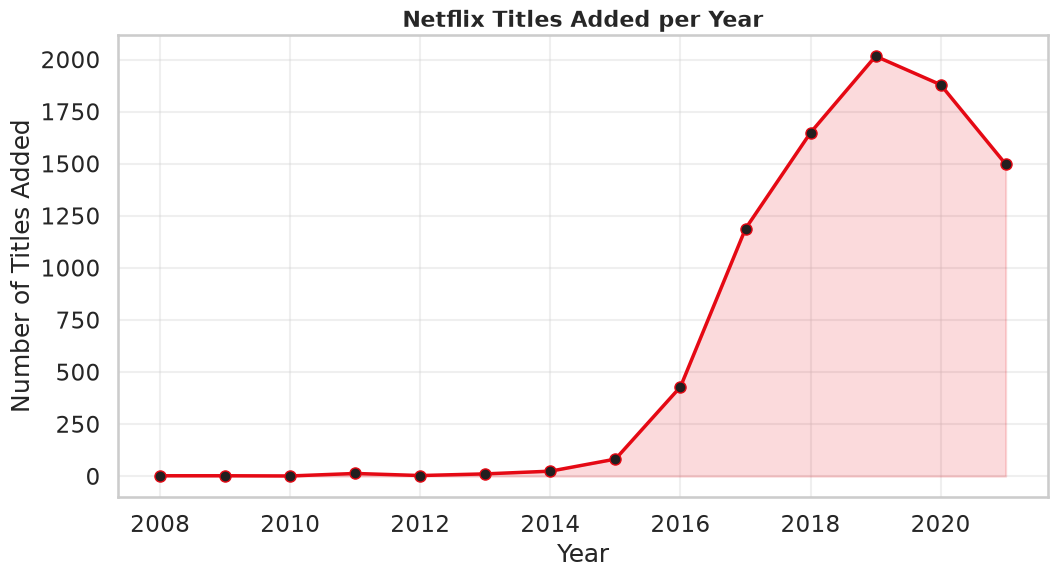

In [17]:
viz.plot_yearly_trend(df);

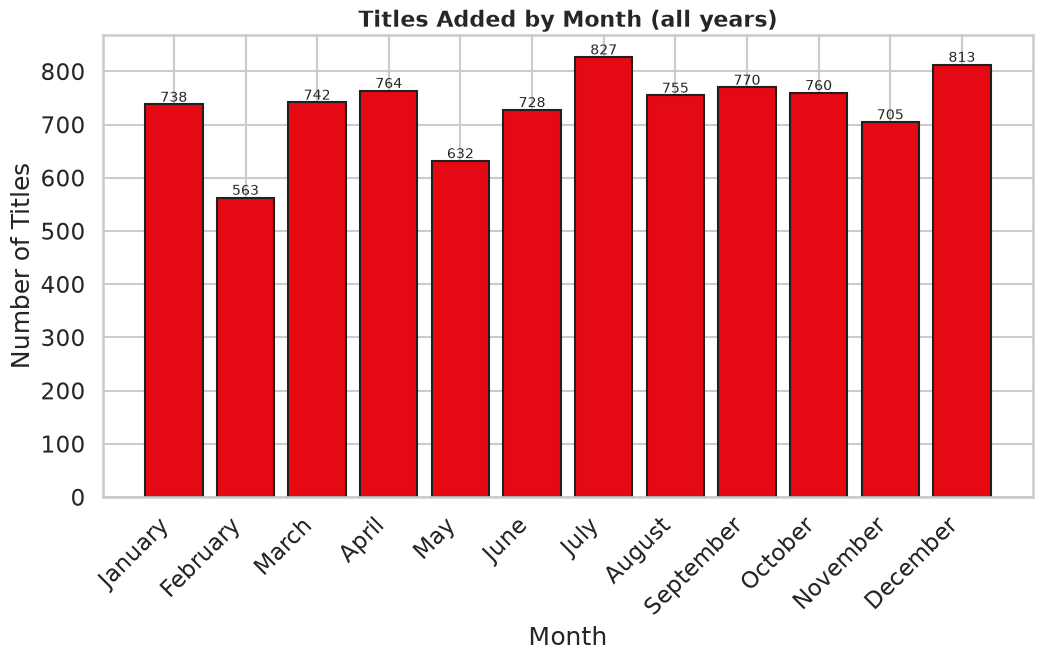

In [18]:
viz.plot_monthly_trend(df);

**Insights**
* Additions exploded from **~500 in 2016 → 2,000+ in 2019**, then plateau/decline in 2020–2021 (COVID production slowdown).
* Monthly seasonality peaks in **July, December, and January** — aligned with holiday viewing windows.
* February is the slowest month for additions — a strategic opportunity for counter-programming.


### Q6. Which directors have the most titles?

In [19]:
analysis.top_directors(df, 10)

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64

**Insights**
* Netflix's top directors are dominated by **Indian filmmakers** (Rajiv Chilaka, Anurag Kashyap etc.) and **stand-up special** directors (Marcus Raboy, Jay Karas).
* Very few Hollywood A-list directors appear — Netflix's supply is deep in mid-budget/regional originals, not blockbusters.


### Q7. Which actors appear most frequently?

In [20]:
analysis.top_actors(df, 10)

cast_list
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64

**Insights**
* The top-appearing actors are heavily **Bollywood** (Shah Rukh Khan, Anupam Kher, Naseeruddin Shah…).
* Reinforces Q1 & Q6 — India is disproportionately represented in Netflix's title volume.


### Q8. Top producing countries (already in Q1)

In [21]:
analysis.top_countries(df, 10)

countries_list
United States     3684
India             1046
United Kingdom     805
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

### Q9. Average movie duration

In [22]:
analysis.movie_duration_stats(df)

count    6131.000000
mean       99.528951
std        28.367576
min         1.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

**Insights**
* Average movie length is **~99 minutes**, median 98 — the classic feature-film runtime.
* Only a very long tail (>3h) skews the mean; interquartile range is a tight 87–115 min.


### Q10. Distribution of movie durations

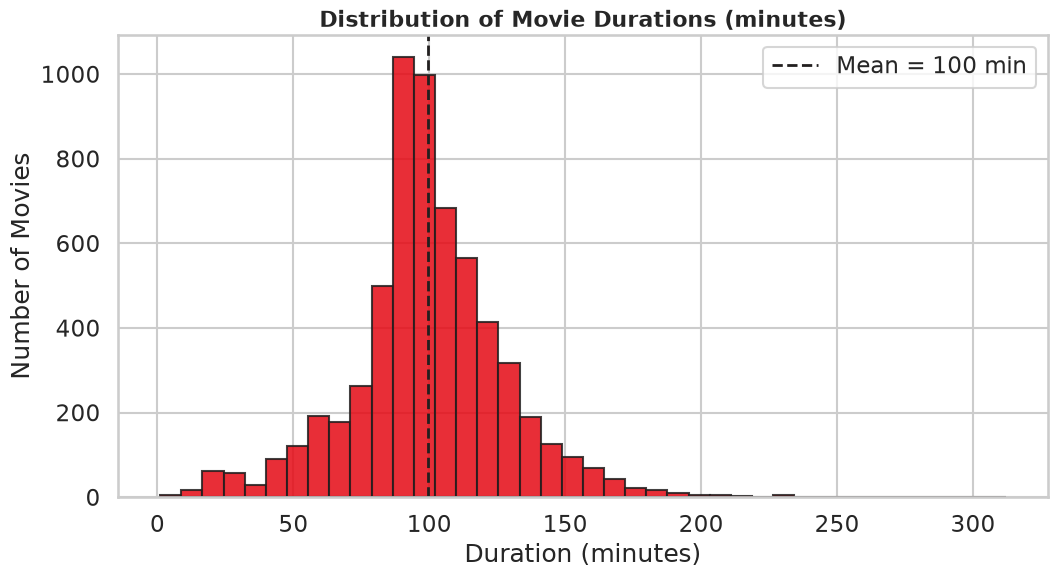

In [23]:
viz.plot_movie_duration_hist(df);

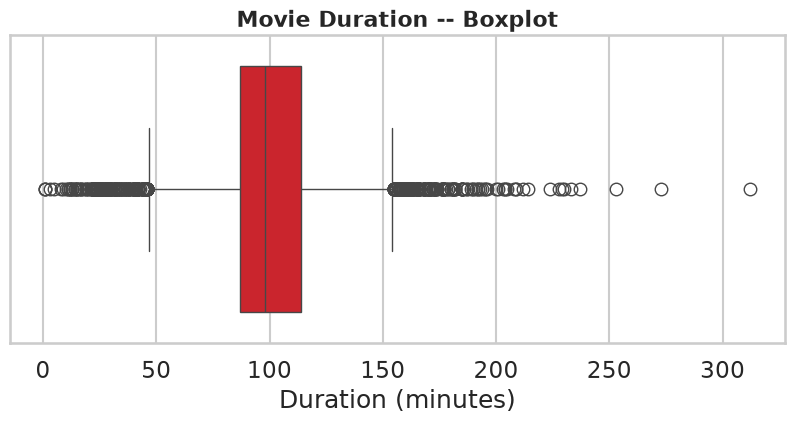

In [24]:
viz.plot_movie_duration_box(df);

**Insights**
* Distribution is roughly normal, centred around 90–100 minutes.
* Outliers include 3+ hour films (mostly Indian and documentary titles).
* Very short (<30 min) items are typically stand-up specials.


### Q11. TV Shows by number of seasons

In [25]:
analysis.tv_seasons_distribution(df).head(10)

duration_seasons
1.0     1793
2.0      421
3.0      198
4.0       94
5.0       64
6.0       33
7.0       23
8.0       17
9.0        9
10.0       6
Name: count, dtype: int64

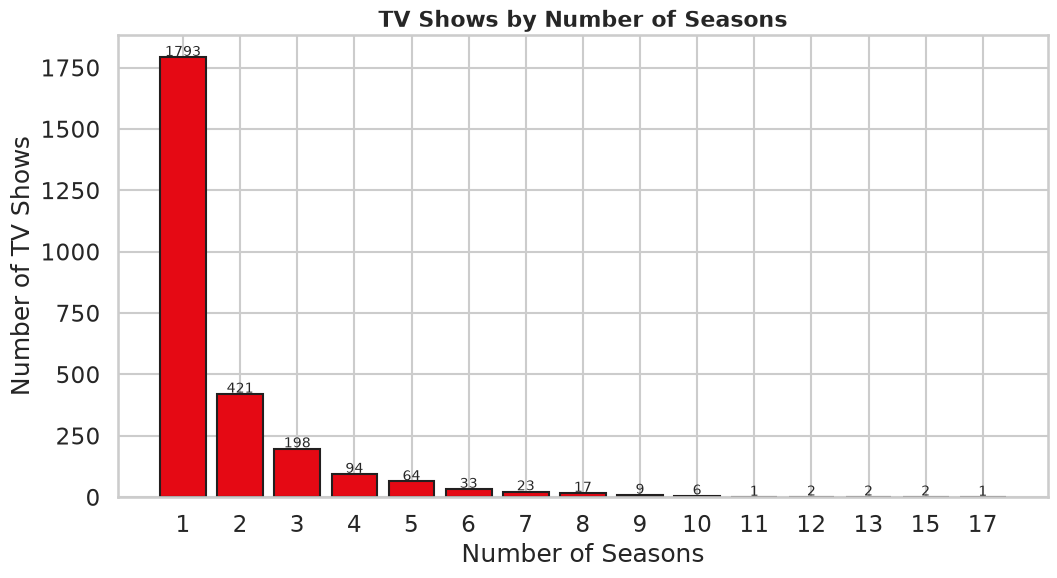

In [26]:
viz.plot_tv_seasons(df);

**Insights**
* The overwhelming majority of TV shows on Netflix have **just 1 season** — reflecting a heavy mix of limited series and cancellations after S1.
* Only a handful of shows exceed 5 seasons — long-running hits are rare and therefore extremely valuable.


### Q12. Which year had the highest number of additions?

In [27]:
print('Peak year:', analysis.peak_year(df))
analysis.yearly_additions(df)

Peak year: 2019


year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

**Insights**
* **2019** is the single biggest year — Netflix's peak content-acquisition burst.
* Post-2019 slowdown correlates with pandemic disruption AND a strategic shift to fewer, higher-quality originals.


### Q13. Which months see the highest content additions?

In [28]:
analysis.monthly_additions(df)

month_added_name
January      738
February     563
March        742
April        764
May          632
June         728
July         827
August       755
September    770
October      760
November     705
December     813
Name: count, dtype: int64

**Insights**
* July, December and January dominate — aligned with summer and winter holiday viewing.
* February is a clear trough — a counter-cyclical launch opportunity.


### Q14. Which genres are growing over time?

In [29]:
analysis.genre_growth(df, top_n=5)

genres_list,Comedies,Documentaries,Dramas,International Movies,International TV Shows
year_added,,,,,
2008,0,0,1,0,0
2009,0,0,1,1,0
2011,0,0,13,1,0
2012,2,1,0,0,0
2013,1,1,0,0,1
2014,2,8,0,2,0
2015,12,13,12,10,3
2016,48,68,65,82,86
2017,177,206,293,395,205


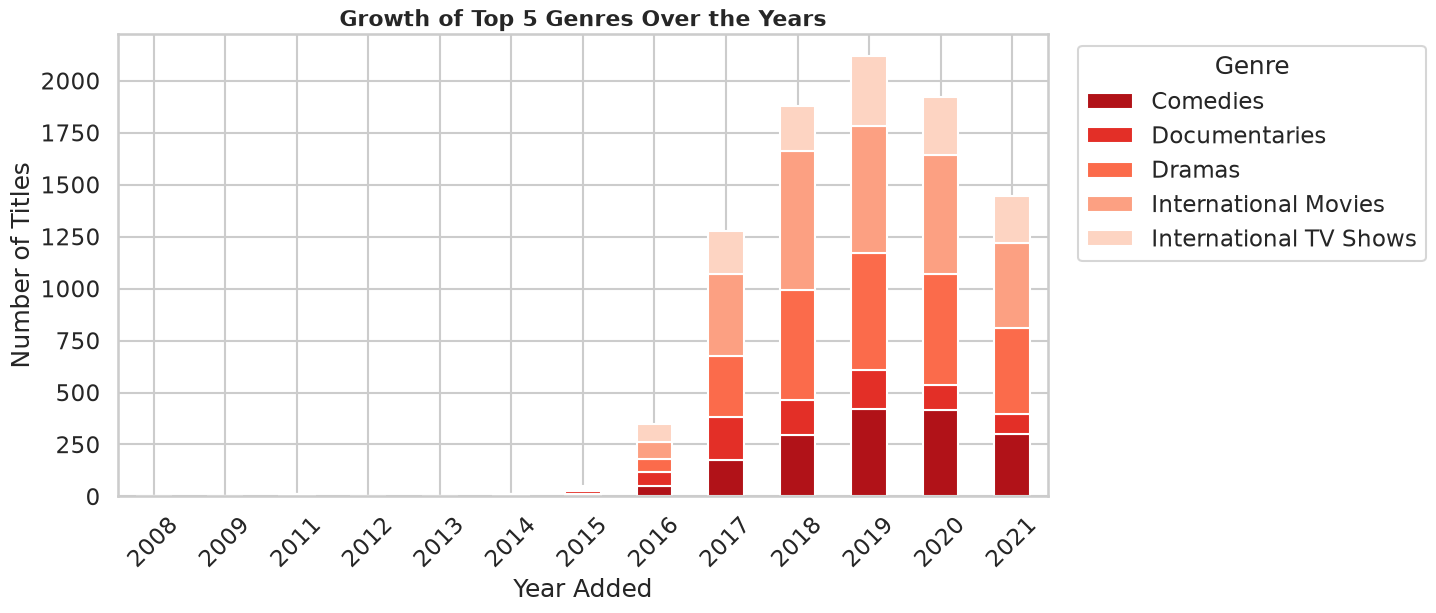

In [30]:
viz.plot_genre_growth_stacked(df, top_n=5);

**Insights**
* **International Movies** and **Dramas** have grown fastest since 2015 — Netflix's international bet.
* Comedies grow more slowly, suggesting the platform's tone is skewing more dramatic over time.


### Q15. Content distribution by rating and type

In [31]:
analysis.rating_by_type(df)

content_type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,4
PG,287,0
PG-13,490,0
R,797,2


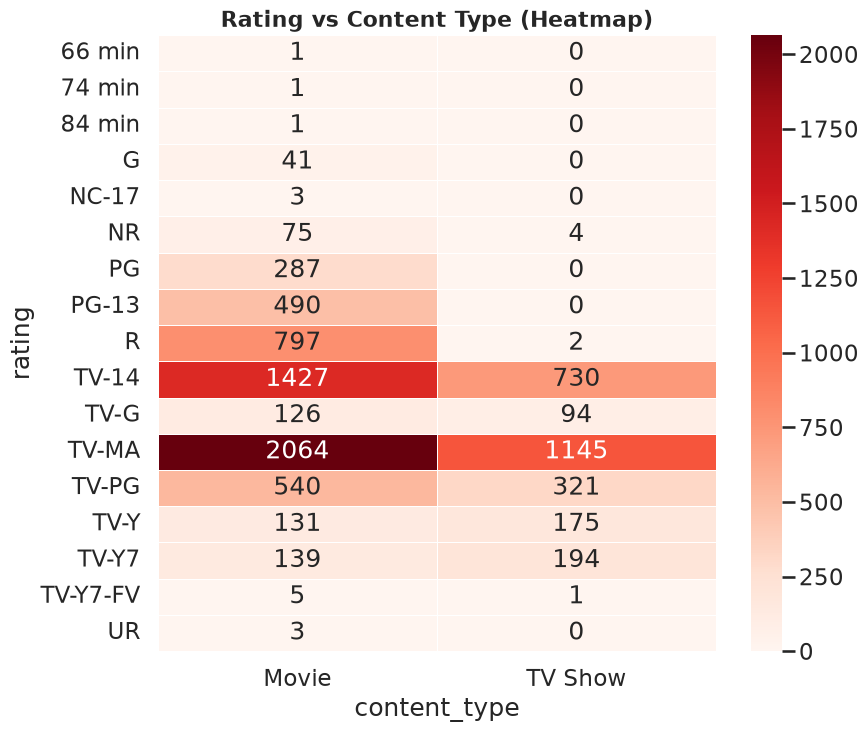

In [32]:
viz.plot_rating_type_heatmap(df);

**Insights**
* TV-MA is dominant in **both** Movies and TV Shows — the mature-adult skew is not a TV-only phenomenon.
* TV-Y / TV-Y7 ratings appear almost exclusively on TV shows — Netflix's kids strategy is series-first.


## 8. Business Insights (Summary)

1. **Catalogue mix is 70% Movies / 30% TV Shows** — Netflix is still film-heavy despite its "series" reputation.
2. **US + India + UK = >50% of titles** — dangerously concentrated; further Latin-American / European sourcing is a lever.
3. **TV-MA content dominates** — Netflix is an adult-first platform; kids content is a growth gap vs Disney+.
4. **2019 was peak additions**, followed by a clear plateau — signals a shift to fewer, higher-budget originals.
5. **International Movies + Dramas are the fastest-growing genres**, a bet that has clearly paid off (Squid Game, Money Heist, RRR-adjacent titles).
6. **TV shows rarely exceed 1 season** — long-running hits are outliers; Netflix's model relies on constant new-series churn.
7. **February is a systemic content trough** — a launch calendar opportunity.
8. **Average movie ≈ 99 min** — Netflix optimises for a single evening's viewing.


## 9. Final Dashboard — KPI Cards & Key Visuals

In [33]:
kpis = analysis.compute_kpis(df)
print('=== KPIs ===')
for k, v in kpis.items():
    print(f'  {k:20s}: {v}')

=== KPIs ===
  total_titles        : 8797
  movies              : 6131
  tv_shows            : 2666
  countries           : 122
  genres              : 42
  most_common_rating  : TV-MA
  top_country         : United States


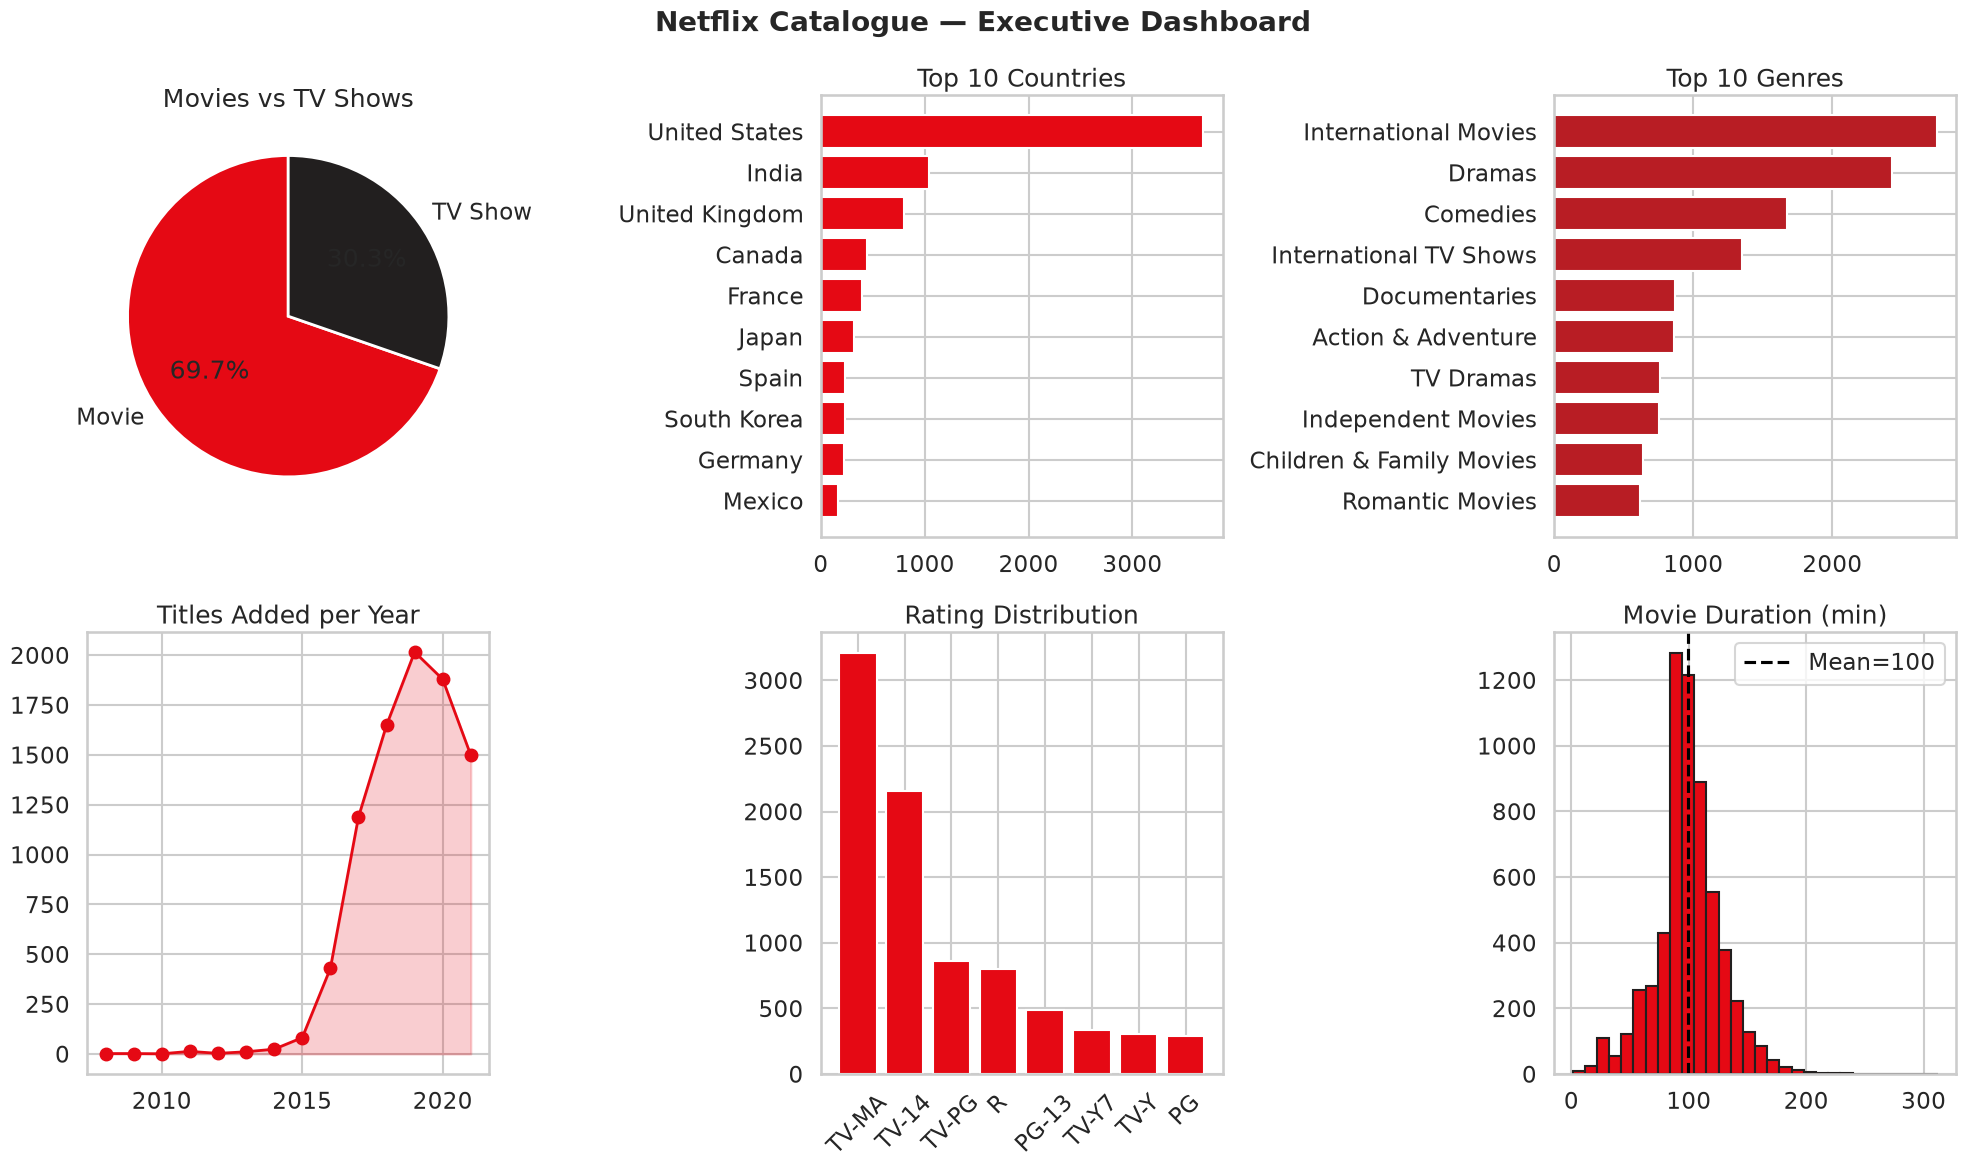

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Netflix Catalogue — Executive Dashboard', fontsize=20, fontweight='bold')

# 1. Movies vs TV
counts = df['content_type'].value_counts()
axes[0, 0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
               colors=['#E50914', '#221F1F'], startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0, 0].set_title('Movies vs TV Shows')

# 2. Top countries
tc = analysis.top_countries(df, 10).sort_values()
axes[0, 1].barh(tc.index, tc.values, color='#E50914')
axes[0, 1].set_title('Top 10 Countries')

# 3. Top genres
tg = analysis.top_genres(df, 10)
axes[0, 2].barh(tg.index[::-1], tg.values[::-1], color='#B81D24')
axes[0, 2].set_title('Top 10 Genres')

# 4. Yearly trend
yr = analysis.yearly_additions(df)
axes[1, 0].plot(yr.index, yr.values, marker='o', color='#E50914', linewidth=2)
axes[1, 0].fill_between(yr.index, yr.values, color='#E50914', alpha=0.2)
axes[1, 0].set_title('Titles Added per Year')

# 5. Ratings
rd = analysis.rating_distribution(df).head(8)
axes[1, 1].bar(rd.index, rd.values, color='#E50914')
axes[1, 1].set_title('Rating Distribution')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Movie duration histogram
minutes = df.loc[df['content_type']=='Movie', 'duration_minutes'].dropna()
axes[1, 2].hist(minutes, bins=30, color='#E50914', edgecolor='#221F1F')
axes[1, 2].axvline(minutes.mean(), color='black', ls='--', label=f'Mean={minutes.mean():.0f}')
axes[1, 2].legend()
axes[1, 2].set_title('Movie Duration (min)')

plt.tight_layout()
plt.show()

## 10. Conclusion
The Netflix catalogue is a **film-heavy, adult-skewing, US-centric** library that has aggressively globalised
(especially into India) between 2016 and 2019, then plateaued. Genre growth is concentrated in International
Movies and Dramas, while kids-oriented content remains under-invested compared to peers.

## 11. Future Improvements
* Merge with **IMDb ratings** to weight the analysis by quality/engagement.
* Add **NLP topic modelling** on `description` to uncover latent genre clusters.
* Build a **Streamlit interactive dashboard** (already included: `dashboard.py`).
* Predict "will this title be added" with a classification model using country/genre/rating features.
* Time-series forecasting of monthly additions for capacity planning.
